# Módulo 4 · SMA y suavizado exponencial simple

Curso: **Series Temporales con R y Python** (Frogames Formación).

Notebook de acompañamiento de la lección `04-tecnicas-de-suavizado/01-sma-y-suavizado-exponencial-simple` — ábrelo mientras lees la lección y ejecuta cada celda tú mismo.

Trabajamos con el dataset clásico de pasajeros de líneas aéreas (`airline_passengers.csv`, en esta misma carpeta): totales mensuales en miles de personas, enero de 1949 a diciembre de 1960.

In [1]:
import matplotlib.pyplot as plt

# Estilo oscuro opcional, para que los gráficos combinen con el tema del curso.
# No afecta a ningún resultado numérico -- puedes omitir esta celda sin problema.
plt.rcParams.update({
    "figure.facecolor": "#0d0d10", "axes.facecolor": "#0d0d10",
    "axes.edgecolor": "#a8a8b3", "axes.labelcolor": "#e1e1e6",
    "xtick.color": "#a8a8b3", "ytick.color": "#a8a8b3",
    "text.color": "#e1e1e6", "grid.color": "#232326",
    "font.size": 11,
})

## Carga del dataset

In [2]:
import pandas as pd
import numpy as np

airline = pd.read_csv("airline_passengers.csv", index_col="Month", parse_dates=True)
airline.dropna(inplace=True)
airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## SMA — media móvil simple

$SMA=\frac{x_1+x_2+...+x_n}{n}$, el promedio aritmético de los últimos $n$ periodos. `rolling(window=n).mean()` lo calcula directamente.

In [3]:
airline["6-month-SMA"] = airline["Thousands of Passengers"].rolling(window=6).mean()
airline["12-month-SMA"] = airline["Thousands of Passengers"].rolling(window=12).mean()
airline.head(15)

,Thousands of Passengers,6-month-SMA,12-month-SMA
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN
1949-06-01,135,124.500000,NaN
1949-07-01,148,130.500000,NaN
1949-08-01,148,135.500000,NaN
1949-09-01,136,136.166667,NaN


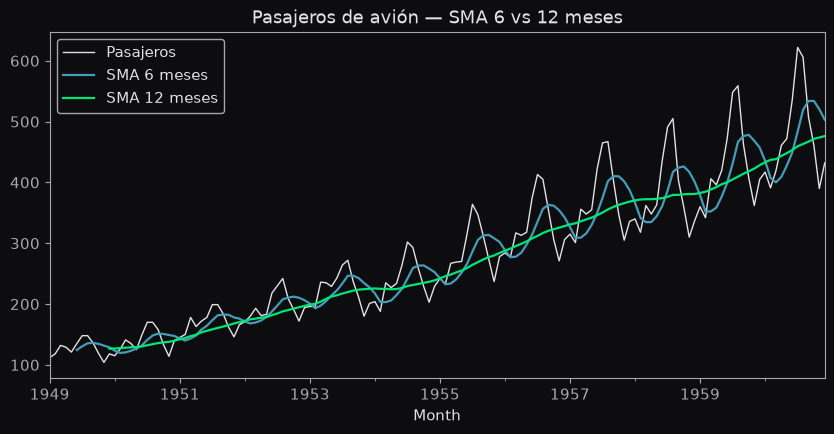

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
airline["Thousands of Passengers"].plot(ax=ax, color="#e1e1e6", linewidth=1, label="Pasajeros")
airline["6-month-SMA"].plot(ax=ax, color="#449cb9", linewidth=1.6, label="SMA 6 meses")
airline["12-month-SMA"].plot(ax=ax, color="#00e676", linewidth=1.6, label="SMA 12 meses")
ax.set_title("Pasajeros de avión — SMA 6 vs 12 meses")
ax.legend()
plt.show()

## EWMA — media móvil ponderada exponencialmente

$y_t = \frac{\sum_{i=0}^{t} w_i x_{t-i}}{\sum_{i=0}^{t} w_i}$, con pesos que decaen exponencialmente en vez de pesar igual los últimos $n$ periodos como hace SMA. Con `span=12` y `adjust=False`, `.ewm()` usa $\alpha = 2/(span+1)$.

In [5]:
airline["EWMA12"] = airline["Thousands of Passengers"].ewm(span=12, adjust=False).mean()
airline[["Thousands of Passengers", "EWMA12"]].head(10)

,Thousands of Passengers,EWMA12
Month,,
1949-01-01,112,112.000000
1949-02-01,118,112.923077
1949-03-01,132,115.857988
1949-04-01,129,117.879836
1949-05-01,121,118.359861
1949-06-01,135,120.919883
1949-07-01,148,125.086055
1949-08-01,148,128.611277
1949-09-01,136,129.748004


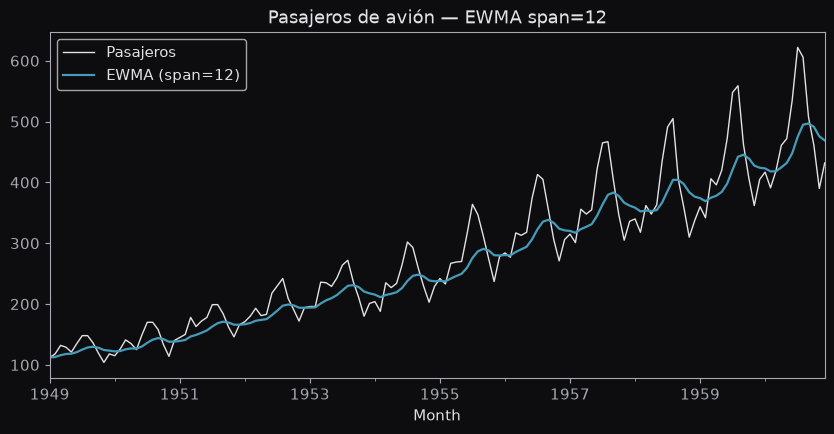

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
airline["Thousands of Passengers"].plot(ax=ax, color="#e1e1e6", linewidth=1, label="Pasajeros")
airline["EWMA12"].plot(ax=ax, color="#449cb9", linewidth=1.6, label="EWMA (span=12)")
ax.set_title("Pasajeros de avión — EWMA span=12")
ax.legend()
plt.show()

## SMA vs EWMA, a igualdad de ventana

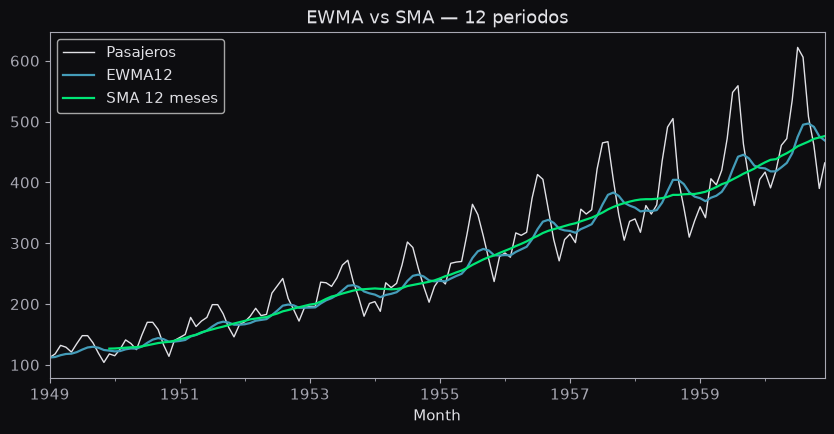

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
airline["Thousands of Passengers"].plot(ax=ax, color="#e1e1e6", linewidth=1, label="Pasajeros")
airline["EWMA12"].plot(ax=ax, color="#449cb9", linewidth=1.6, label="EWMA12")
airline["12-month-SMA"].plot(ax=ax, color="#00e676", linewidth=1.6, label="SMA 12 meses")
ax.set_title("EWMA vs SMA — 12 periodos")
ax.legend()
plt.show()

**Entregable**: reproduce estas celdas con `window`/`span` distintos (prueba 3 y 24) y, en tus notas, anota qué le pasa al retraso (*lag*) de la curva suavizada frente a los picos reales según creces la ventana. Ese retraso es exactamente el problema que Holt-Winters (siguiente lección) viene a resolver cuando hay tendencia.